# Phase 1: Data Foundation

**Goal:** Build a single clean DataFrame (Jan 2000 – Dec 2023) with all raw series and derived features.  
**Deliverables:** `data/raw/master.csv` + 3 validation visualizations.

**Data sources:**
- Yahoo Finance: `^GSPC` (S&P 500), `^VIX`, sector ETFs (`XLK`, `XLF`, `XLE`, `XLV`, `XLY`, `XLP`)
- FRED: 10Y Treasury (`DGS10`), 2Y Treasury (`DGS2`), Fed Funds Rate (`FEDFUNDS`)

**Derived features:**
- `sp500_return`: daily log return of S&P 500
- `realized_vol_20d`: 20-day rolling std of daily returns × √252
- `yield_spread`: DGS10 − DGS2
- `growth_value_spread`: XLK − XLP (growth vs defensive proxy)

**Success criteria:**
- Zero missing values after cleaning
- Directional accuracy in returns sanity check: ~50% (not >60%)
- All 3 validation plots rendered cleanly

## 0. Imports & Config

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import yfinance as yf
import pandas_datareader.data as web
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True

# Paths
DATA_RAW = Path('../data/raw')
FIGURES  = Path('../results/figures')

# Date range
START = '2000-01-01'
END   = '2023-12-31'

# Tickers
YAHOO_TICKERS = ['^GSPC', '^VIX', 'XLK', 'XLF', 'XLE', 'XLV', 'XLY', 'XLP']
FRED_SERIES   = {'DGS10': 'treasury_10y', 'DGS2': 'treasury_2y', 'FEDFUNDS': 'fed_funds_rate'}

print('Setup complete.')

Setup complete.


## 1. Download Raw Data

In [2]:
# --- 1a. Yahoo Finance ---
raw_yahoo = yf.download(YAHOO_TICKERS, start=START, end=END, auto_adjust=True)['Close']
raw_yahoo.columns = [t.replace('^', '').lower() for t in raw_yahoo.columns]
print('Yahoo shape:', raw_yahoo.shape)
raw_yahoo.head()


[                       0%                       ]


[************          25%                       ]  2 of 8 completed


[******************    38%                       ]  3 of 8 completed


[**********************50%                       ]  4 of 8 completed


[**********************62%*****                  ]  5 of 8 completed


[**********************75%***********            ]  6 of 8 completed


[**********************88%*****************      ]  7 of 8 completed


[*********************100%***********************]  8 of 8 completed

Yahoo shape: (6037, 8)


,xle,xlf,xlk,xlp,xlv,xly,gspc,vix
Date,,,,,,,,
2000-01-03,6.655916,11.090903,20.626389,12.138824,20.440741,11.151033,1455.219971,24.209999
2000-01-04,6.530632,10.606054,19.579952,11.797002,19.976904,10.815575,1399.420044,27.010000
2000-01-05,6.702902,10.522720,19.289278,12.005427,19.797691,10.682554,1402.109985,26.410000
2000-01-06,6.961310,10.984841,18.649786,12.230532,19.860945,10.804008,1403.449951,25.730000
2000-01-07,7.035692,11.166656,18.975344,13.005886,20.103409,11.312977,1441.469971,21.719999


In [3]:
# --- 1b. FRED ---
fred_frames = []
for series_id, col_name in FRED_SERIES.items():
    s = web.DataReader(series_id, 'fred', START, END)
    s.columns = [col_name]
    fred_frames.append(s)

raw_fred = pd.concat(fred_frames, axis=1)
print('FRED shape:', raw_fred.shape)
raw_fred.head()

FRED shape: (6343, 3)


,treasury_10y,treasury_2y,fed_funds_rate
DATE,,,
2000-01-01,NaN,NaN,5.45
2000-01-03,6.58,6.38,NaN
2000-01-04,6.49,6.30,NaN
2000-01-05,6.62,6.38,NaN
2000-01-06,6.57,6.35,NaN


## 2. Merge into Single DataFrame

In [4]:
# Align on trading days (Yahoo index), forward-fill FRED weekend/holiday gaps
df = raw_yahoo.copy()
fred_aligned = raw_fred.reindex(df.index).ffill()
df = pd.concat([df, fred_aligned], axis=1)

# Drop rows where S&P 500 is NaN (non-trading days)
df = df.dropna(subset=['gspc'])

print('Merged shape:', df.shape)
print('Date range:', df.index.min(), '→', df.index.max())
df.head()

Merged shape: (6037, 11)
Date range: 2000-01-03 00:00:00 → 2023-12-29 00:00:00


,xle,xlf,xlk,xlp,xlv,xly,gspc,vix,treasury_10y,treasury_2y,fed_funds_rate
Date,,,,,,,,,,,
2000-01-03,6.655916,11.090903,20.626389,12.138824,20.440741,11.151033,1455.219971,24.209999,6.58,6.38,NaN
2000-01-04,6.530632,10.606054,19.579952,11.797002,19.976904,10.815575,1399.420044,27.010000,6.49,6.30,NaN
2000-01-05,6.702902,10.522720,19.289278,12.005427,19.797691,10.682554,1402.109985,26.410000,6.62,6.38,NaN
2000-01-06,6.961310,10.984841,18.649786,12.230532,19.860945,10.804008,1403.449951,25.730000,6.57,6.35,NaN
2000-01-07,7.035692,11.166656,18.975344,13.005886,20.103409,11.312977,1441.469971,21.719999,6.52,6.31,NaN


## 3. Compute Derived Features

In [5]:
# Daily log return of S&P 500
df['sp500_return'] = np.log(df['gspc'] / df['gspc'].shift(1))

# 20-day realized annualized volatility
df['realized_vol_20d'] = df['sp500_return'].rolling(20).std() * np.sqrt(252)

# Yield curve spread (10Y - 2Y)
df['yield_spread'] = df['treasury_10y'] - df['treasury_2y']

# Growth vs value spread (XLK - XLP, log ratio)
df['growth_value_spread'] = np.log(df['xlk'] / df['xlp'])

# Drop first 20 rows (NaN from rolling window)
df = df.dropna()

print('Final shape after feature engineering:', df.shape)
print('Missing values:\n', df.isnull().sum())
df[['sp500_return', 'realized_vol_20d', 'yield_spread', 'growth_value_spread']].describe()

Final shape after feature engineering: (6017, 15)
Missing values:
 xle                    0
xlf                    0
xlk                    0
xlp                    0
xlv                    0
xly                    0
gspc                   0
vix                    0
treasury_10y           0
treasury_2y            0
fed_funds_rate         0
sp500_return           0
realized_vol_20d       0
yield_spread           0
growth_value_spread    0
dtype: int64


,sp500_return,realized_vol_20d,yield_spread,growth_value_spread
count,6017.000000,6017.000000,6017.000000,6017.000000
mean,0.000204,0.165526,1.140926,-0.439371
std,0.012364,0.108197,0.967910,0.326927
min,-0.127652,0.032837,-1.080000,-0.965476
25%,-0.004882,0.097369,0.270000,-0.675157
50%,0.000592,0.139052,1.210000,-0.558804
75%,0.005916,0.201416,1.940000,-0.270320
max,0.109572,0.978970,2.910000,0.791695


In [6]:
# Save master CSV
DATA_RAW.mkdir(parents=True, exist_ok=True)
df.to_csv(DATA_RAW / 'master.csv')
print('Saved to', DATA_RAW / 'master.csv')

Saved to ../data/raw/master.csv


## 4. Validation Visualizations

### VIZ 1.1 — Feature Dashboard (S&P 500, VIX, Yield Spread, Realized Vol)

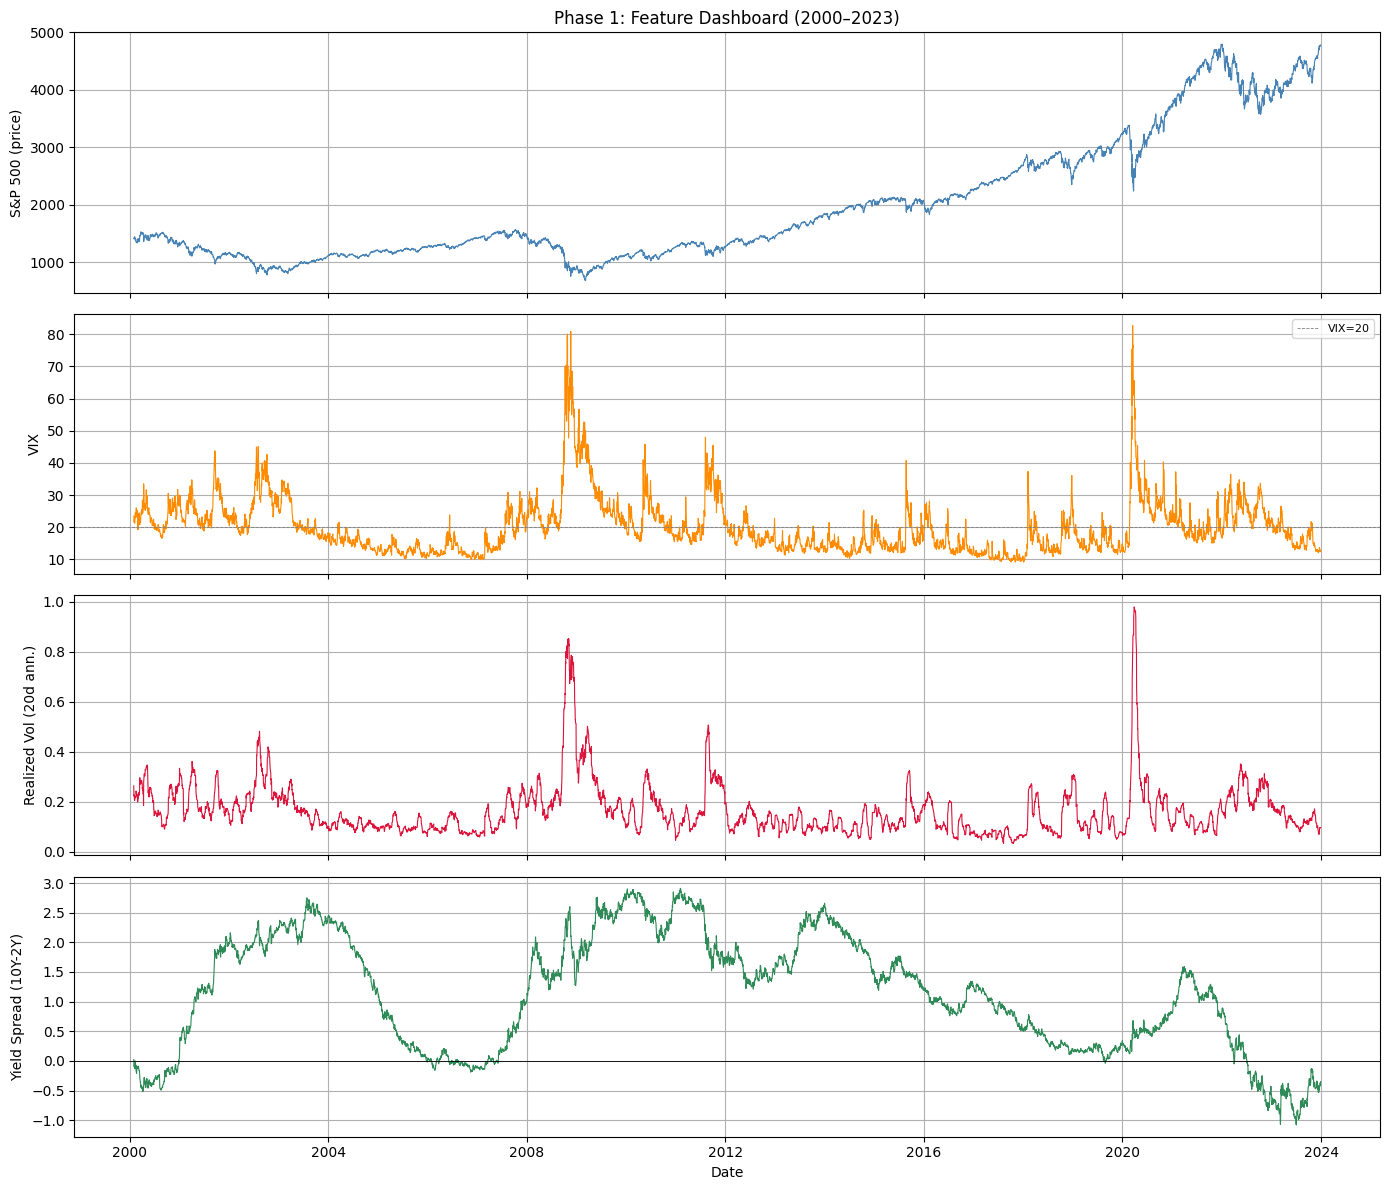

In [7]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

axes[0].plot(df.index, df['gspc'], color='steelblue', linewidth=0.8)
axes[0].set_ylabel('S&P 500 (price)')
axes[0].set_title('Phase 1: Feature Dashboard (2000–2023)')

axes[1].plot(df.index, df['vix'], color='darkorange', linewidth=0.8)
axes[1].set_ylabel('VIX')
axes[1].axhline(20, color='gray', linestyle='--', linewidth=0.6, label='VIX=20')
axes[1].legend(fontsize=8)

axes[2].plot(df.index, df['realized_vol_20d'], color='crimson', linewidth=0.8)
axes[2].set_ylabel('Realized Vol (20d ann.)')

axes[3].plot(df.index, df['yield_spread'], color='seagreen', linewidth=0.8)
axes[3].axhline(0, color='black', linewidth=0.6)
axes[3].set_ylabel('Yield Spread (10Y-2Y)')
axes[3].set_xlabel('Date')

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
FIGURES.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES / 'viz_1_1_feature_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 1.2 — Correlation Heatmap

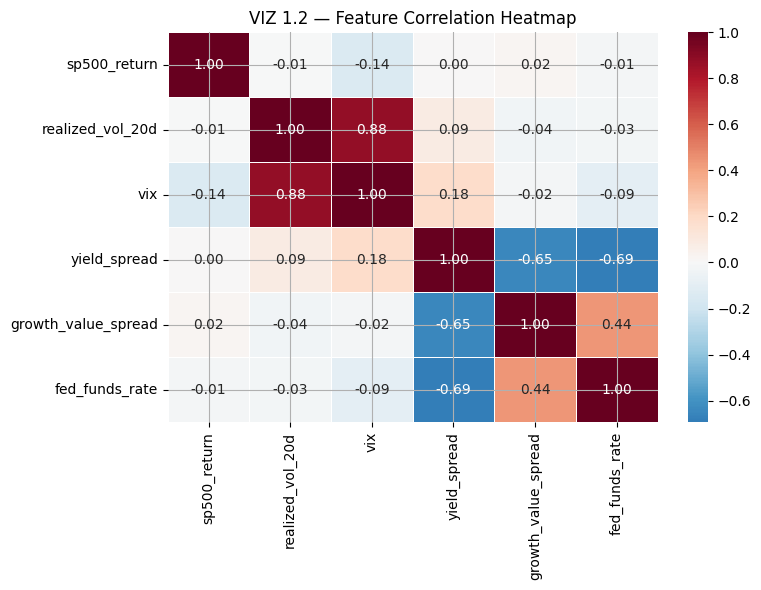

In [8]:
feature_cols = ['sp500_return', 'realized_vol_20d', 'vix', 'yield_spread',
                'growth_value_spread', 'fed_funds_rate']

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('VIZ 1.2 — Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIGURES / 'viz_1_2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### VIZ 1.3 — Missing Data Audit

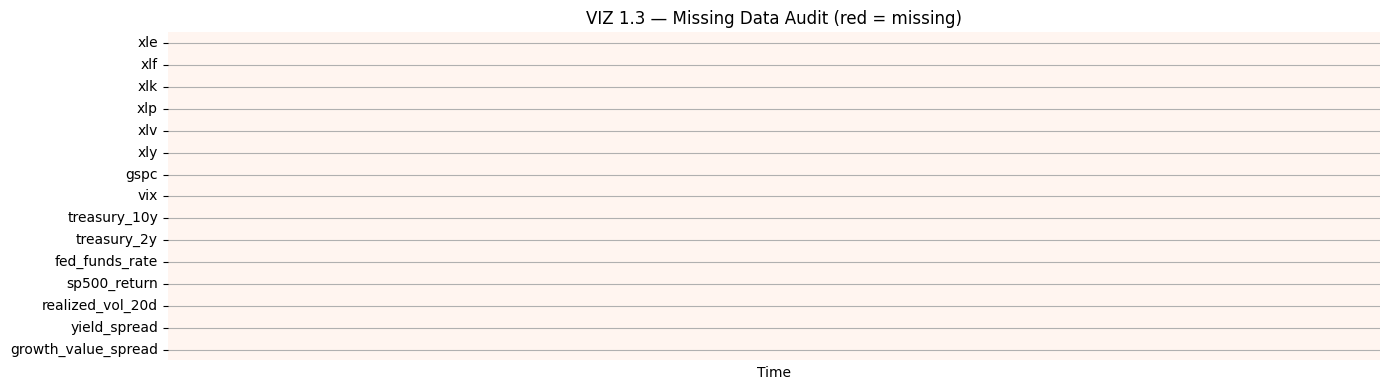


Missing value counts:
xle                    0
xlf                    0
xlk                    0
xlp                    0
xlv                    0
xly                    0
gspc                   0
vix                    0
treasury_10y           0
treasury_2y            0
fed_funds_rate         0
sp500_return           0
realized_vol_20d       0
yield_spread           0
growth_value_spread    0
dtype: int64


In [9]:
# Heatmap of missing data presence across time (using a sample)
missing = df.isnull().astype(int)

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(missing.T, cbar=False, cmap='Reds', ax=ax, xticklabels=False)
ax.set_title('VIZ 1.3 — Missing Data Audit (red = missing)')
ax.set_xlabel('Time')
plt.tight_layout()
plt.savefig(FIGURES / 'viz_1_3_missing_data_audit.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nMissing value counts:')
print(df.isnull().sum())

## 5. Phase 1 Gate Check

Run this cell last — all assertions must pass before moving to Phase 2.

In [ ]:
# Gate: no missing values
assert df.isnull().sum().sum() == 0, 'FAIL: missing values present'

# Gate: date range coverage
assert df.index.min().year <= 2000, 'FAIL: data does not start in 2000'
assert df.index.max().year >= 2023, 'FAIL: data does not reach 2023'

# Gate: directional accuracy sanity (50±5%)
dir_acc = (np.sign(df['sp500_return']) == np.sign(df['sp500_return'].shift(1))).mean()
assert 0.45 < dir_acc < 0.60, f'FAIL: suspicious directional accuracy {dir_acc:.3f} (expect 0.45–0.60)'

# Gate: required columns present
required = ['sp500_return', 'realized_vol_20d', 'vix', 'yield_spread',
            'growth_value_spread', 'fed_funds_rate']
for col in required:
    assert col in df.columns, f'FAIL: missing column {col}'

print('All Phase 1 gate checks PASSED.')
print(f'Dataset: {len(df):,} trading days | {df.index.min().date()} → {df.index.max().date()}')

All Phase 1 gate checks PASSED.
Dataset: 6,017 trading days | 2000-02-01 → 2023-12-29
